## Name: <span style="color:blue"> *David Taylor* </span>

In [1]:
# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Data Exploration

In [4]:
df = pd.read_csv("online_gaming_behavior_dataset.csv")

print(df.shape)

print(df.columns)

print(df.head())

print(df.isnull().sum())

(40034, 13)
Index(['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours',
       'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek',
       'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked',
       'EngagementLevel'],
      dtype='object')
   PlayerID  Age  Gender Location GameGenre  PlayTimeHours  InGamePurchases  \
0      9000   43    Male    Other  Strategy      16.271119                0   
1      9001   29  Female      USA  Strategy       5.525961                0   
2      9002   22  Female      USA    Sports       8.223755                0   
3      9003   35    Male      USA    Action       5.265351                1   
4      9004   33    Male   Europe    Action      15.531945                0   

  GameDifficulty  SessionsPerWeek  AvgSessionDurationMinutes  PlayerLevel  \
0         Medium                6                        108           79   
1         Medium                5                        144           11   
2           Easy 

In [5]:
# Visualizations of PlayTimeHours, SessionsPerWeek, and AvgSessionDurationMinutes

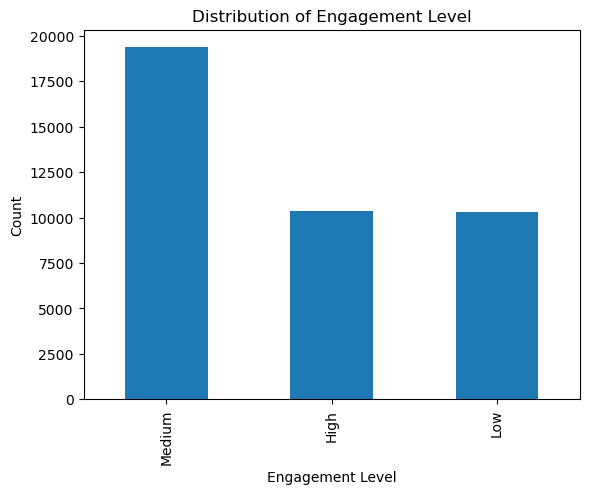

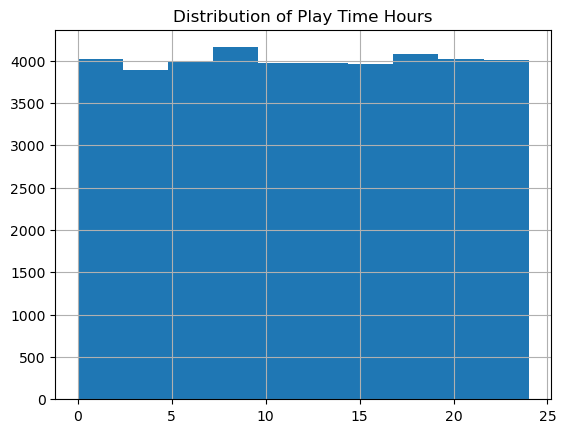

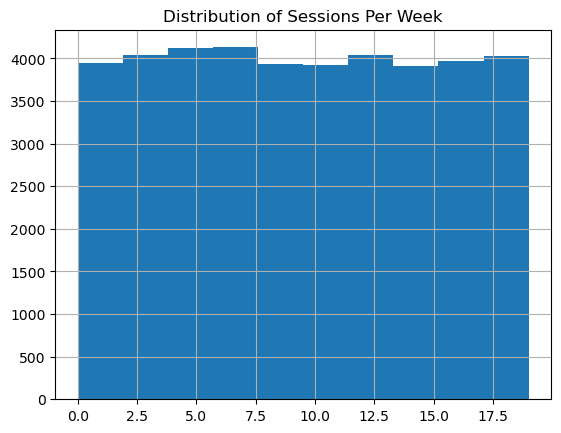

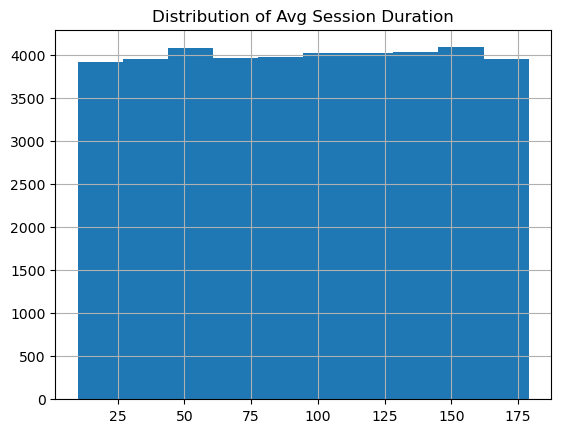

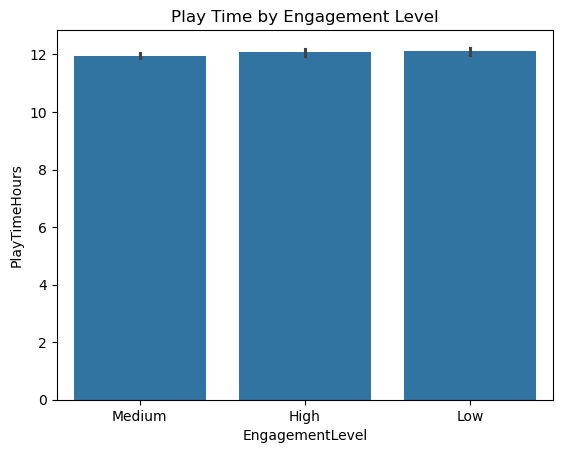

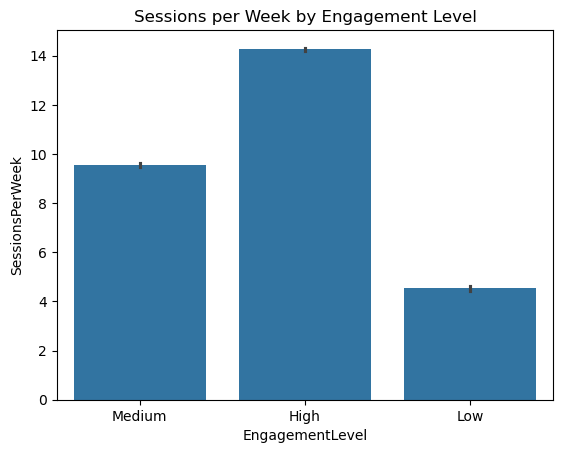

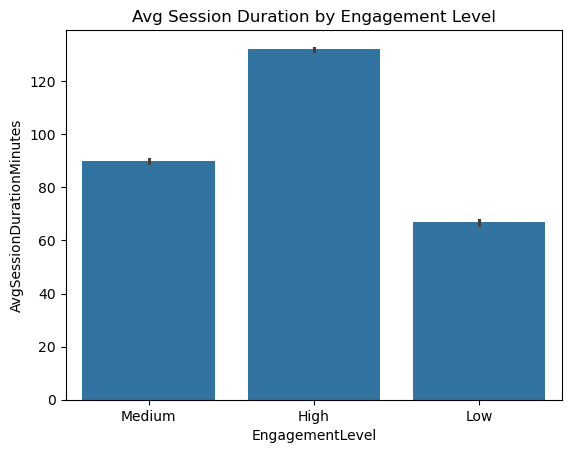

In [6]:
df['EngagementLevel'].value_counts().plot(kind='bar')
plt.title("Distribution of Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Count")
plt.show()

df['PlayTimeHours'].hist()
plt.title("Distribution of Play Time Hours")
plt.show()

df['SessionsPerWeek'].hist()
plt.title("Distribution of Sessions Per Week")
plt.show()

df['AvgSessionDurationMinutes'].hist()
plt.title("Distribution of Avg Session Duration")
plt.show()

plt.figure()
sns.barplot(x='EngagementLevel', y='PlayTimeHours', data=df)
plt.title("Play Time by Engagement Level")
plt.show()

plt.figure()
sns.barplot(x='EngagementLevel', y='SessionsPerWeek', data=df)
plt.title("Sessions per Week by Engagement Level")
plt.show()

plt.figure()
sns.barplot(x='EngagementLevel', y='AvgSessionDurationMinutes', data=df)
plt.title("Avg Session Duration by Engagement Level")
plt.show()

In [7]:
# GameDifficulty

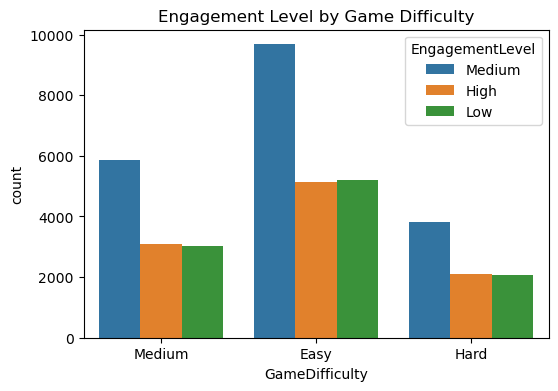

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='GameDifficulty', hue='EngagementLevel', data=df)
plt.title("Engagement Level by Game Difficulty")
plt.show()

In [9]:
# Define Targets, Features, Columns

In [10]:
df = df.drop(columns=['PlayerID'])
X = df.drop(columns=['EngagementLevel'])
y = df['EngagementLevel']

num_features = [
    'Age',
    'PlayTimeHours',
    'SessionsPerWeek',
    'AvgSessionDurationMinutes',
    'PlayerLevel',
    'AchievementsUnlocked',
    'InGamePurchases'
]

cat_features = [
    'Gender',
    'Location',
    'GameGenre',
    'GameDifficulty'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

In [11]:
# train/test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# Logistic Regression

In [14]:
log_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=10000))
])

In [15]:
# K-NN

In [16]:
knn = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

In [17]:
# Training Models

In [18]:
log_reg.fit(X_train, y_train);
knn.fit(X_train, y_train);

In [19]:
# Predictions

C:\Users\dtayl\anaconda3\envs\itcs-3156\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


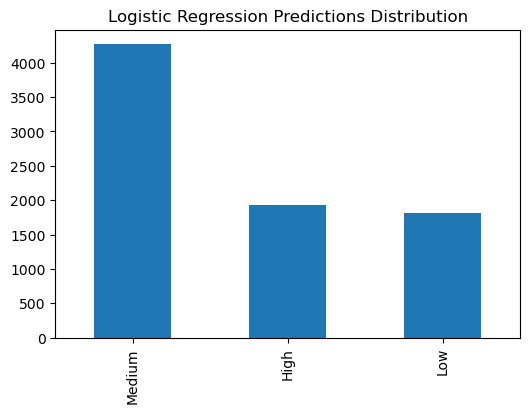

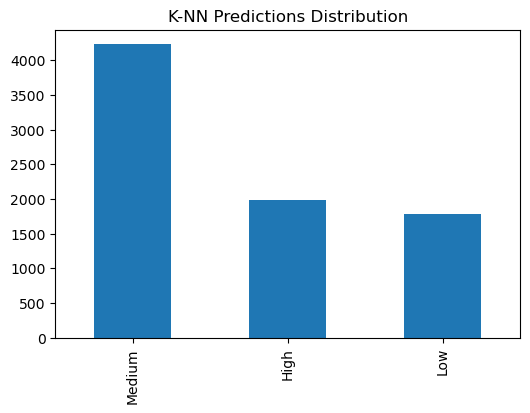

In [20]:
lr_pred = log_reg.predict(X_test)
knn_pred = knn.predict(X_test)

plt.figure(figsize=(6,4))
pd.Series(lr_pred).value_counts().plot(kind='bar')
plt.title("Logistic Regression Predictions Distribution")
plt.show()

plt.figure(figsize=(6,4))
pd.Series(knn_pred).value_counts().plot(kind='bar')
plt.title("K-NN Predictions Distribution")
plt.show()

In [21]:
# Results

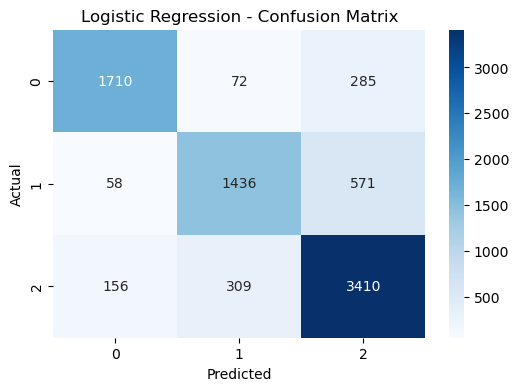

Logistic Regression Accuracy: 0.8188


In [22]:
lr_acc = accuracy_score(y_test, lr_pred)

cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

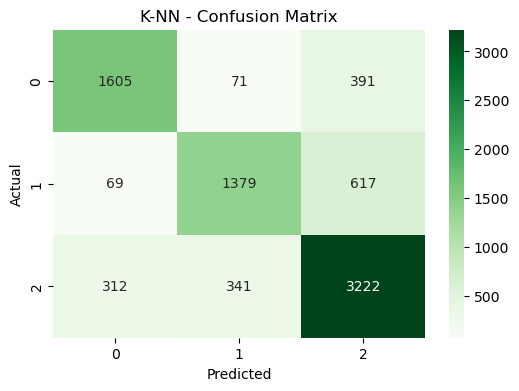

K-NN Accuracy: 0.7751


In [23]:
knn_acc = accuracy_score(y_test, knn_pred)

cm_knn = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title("K-NN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"K-NN Accuracy: {knn_acc:.4f}")